# 2D Trajectory Tracking: LQR vs MPC

This notebook demonstrates trajectory tracking for a 2D position system with inertia.
The plant is a **4th order system** — two coupled 2nd order subsystems (X and Y axes),
each modelled as a servo with viscous friction and inertia.

**State vector:** `x = [pos_x, pos_y, vel_x, vel_y]`  
**Control input:** `u = [force_x, force_y]`

We compare two controllers:
- **LQR with integral action** — optimal state-feedback, uses only the current reference
- **MPC (Model Predictive Control)** — exploits a *prediction horizon* of future reference trajectory to anticipate turns and reduce tracking error

## 1. Imports and Setup

In [1]:
import numpy
import matplotlib
import matplotlib.pyplot as plt
import AILibs

## 2. Position Model (2D with Inertia)

Each axis is a 2nd order system:

$$\dot{v} = -\frac{1}{\tau} v + \frac{k}{\tau} u, \qquad \dot{p} = v$$

Combined into a 4-state system for X and Y:

$$
A = \begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & -1/\tau & 0 \\
0 & 0 & 0 & -1/\tau
\end{bmatrix},
\quad
B = \begin{bmatrix}
0 & 0 \\
0 & 0 \\
k/\tau & 0 \\
0 & k/\tau
\end{bmatrix}
$$

In [2]:
class PositionModel(AILibs.DynamicalSystem):

    def __init__(self, tau, k, dt):
        a_tmp = -1.0/tau
        b_tmp = k*1.0/tau

        a_mat = numpy.array([
            [0.0,   0.0,    1.0,     0.0],
            [0.0,   0.0,    0.0,     1.0],
            [0.0,   0.0,    a_tmp,   0.0],
            [0.0,   0.0,    0.0,     a_tmp]
        ])

        b_mat = numpy.array([
            [0.0,   0.0],
            [0.0,   0.0],
            [b_tmp, 0.0],
            [0.0,   b_tmp],
        ])

        AILibs.DynamicalSystem.__init__(self, a_mat, b_mat, None, dt)

## 3. System Parameters

In [3]:
dt      = 0.01
u_limit = 10

# plant parameters
tau = 0.5       # time constant (inertia)
k   = 0.3       # gain

# simulation length
n_steps = 1000

## 4. Reference Trajectory Generator

We generate a square-corner trajectory that visits four waypoints in sequence.
The MPC controller receives the full future trajectory over its prediction horizon,
while LQR only sees the current setpoint.

In [4]:
def get_required(n, n_steps, prediction_horizon, n_states):
    """Generate reference trajectory over the prediction horizon."""
    Xr = []
    for h in range(prediction_horizon):
        turn_state = ((n + h) // (n_steps // 4)) % 4

        if turn_state == 0:
            x_pos_req = 1.0
            y_pos_req = 0.0
        elif turn_state == 1:
            x_pos_req = 1.0
            y_pos_req = 1.0
        elif turn_state == 2:
            x_pos_req = 0.0
            y_pos_req = 1.0
        else:
            x_pos_req = 0.0
            y_pos_req = 0.0

        xr = numpy.zeros((n_states, 1))
        xr[0, 0] = x_pos_req
        xr[1, 0] = y_pos_req

        Xr.append(xr)

    Xr = numpy.vstack(Xr)
    return Xr

## 5. Open-Loop Step Response

First, let's observe the uncontrolled plant response to a step input on both axes.

mat_a = 
0.0 0.0 1.0 0.0 
0.0 0.0 0.0 1.0 
0.0 0.0 -2.0 0.0 
0.0 0.0 0.0 -2.0 


mat_b = 
0.0 0.0 
0.0 0.0 
0.6 0.0 
0.0 0.6 


mat_c = 
1.0 0.0 0.0 0.0 
0.0 1.0 0.0 0.0 
0.0 0.0 1.0 0.0 
0.0 0.0 0.0 1.0 





<Figure size 640x480 with 0 Axes>

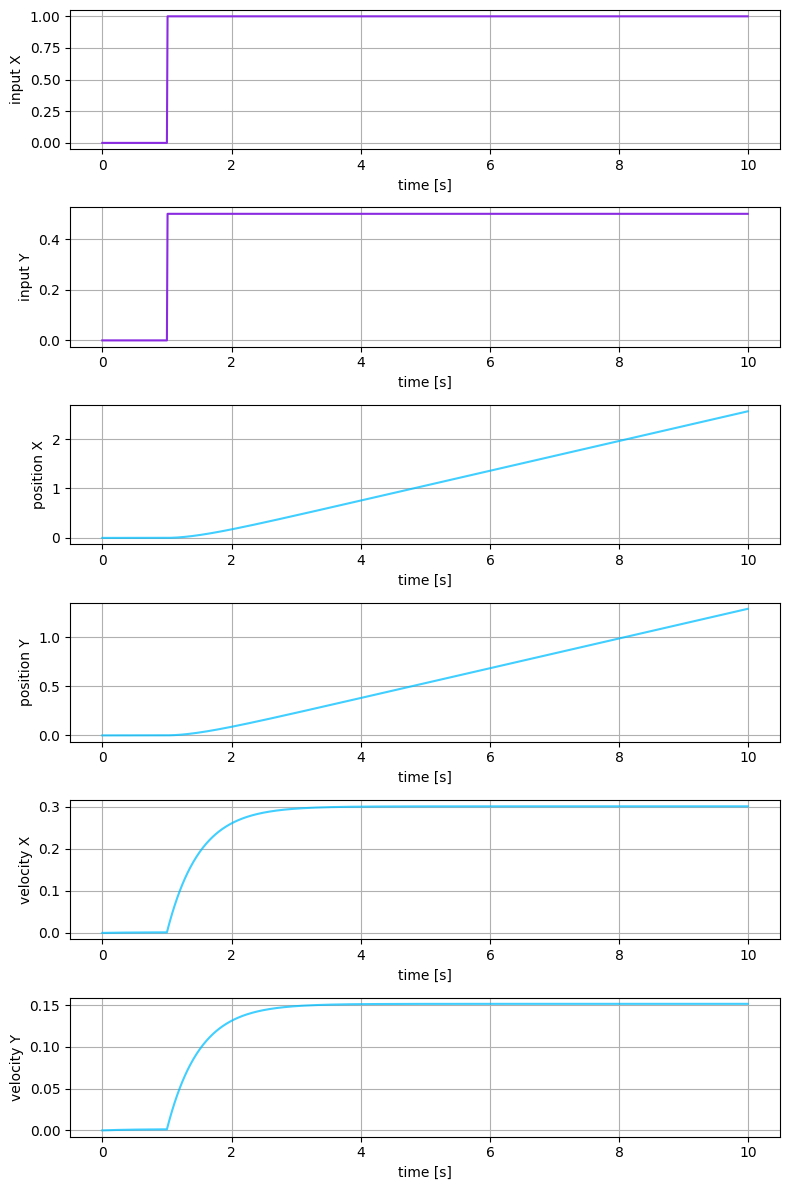

In [5]:
ds_ol = PositionModel(tau, k, dt)
print(ds_ol)

x = numpy.zeros((ds_ol.a.shape[0], 1))

t_result = []
u_result = []
x_result = []

for n in range(n_steps):
    if n > n_steps * 0.1:
        u = numpy.array([[1.0], [0.5]])
    else:
        u = numpy.array([[0.0], [0.0]])

    x, _ = ds_ol.forward(x, u)

    t_result.append(n * dt)
    u_result.append(u[:, 0])
    x_result.append(x[:, 0])

AILibs.plot_response(
    t_result, u_result, x_result,
    "plots/trajectory_step_response.png",
    ["input X", "input Y"],
    ["position X", "position Y", "velocity X", "velocity Y"]
)

The position integrates velocity — the system is a **double integrator** with first-order lag.
Without feedback the position grows without bound.

## 6. Discretise the Plant

Both controllers operate on the discretised system.

In [6]:
ds = PositionModel(tau, k, dt)

a_disc, b_disc, _ = AILibs.c2d(ds.a, ds.b, None, dt)

print("A_d =\n", numpy.round(a_disc, 6))
print("B_d =\n", numpy.round(b_disc, 6))

A_d =
 [[1.       0.       0.009901 0.      ]
 [0.       1.       0.       0.009901]
 [0.       0.       0.980198 0.      ]
 [0.       0.       0.       0.980198]]
B_d =
 [[3.000e-05 0.000e+00]
 [0.000e+00 3.000e-05]
 [5.941e-03 0.000e+00]
 [0.000e+00 5.941e-03]]


## 7. LQR Controller with Integral Action

LQR minimises an infinite-horizon quadratic cost.
We add integral action so the controller can eliminate steady-state error.

**Tuning:** penalise position error (`Q`), moderate control effort (`R`).

In [7]:
q_lqr = numpy.diag([1.0, 1.0, 0.0, 0.0])
r_lqr = numpy.diag([1.0, 1.0])

lqr_controller = AILibs.LQRIDiscrete(a_disc, b_disc, q_lqr, r_lqr, u_limit)

print("k  =", lqr_controller.k)
print("ki =", lqr_controller.ki)

k  = [[53.79105754  0.         10.42630178  0.        ]
 [ 0.         53.79105754  0.         10.42630178]]
ki = [[1.03127891 0.         0.         0.        ]
 [0.         1.03127891 0.         0.        ]]


## 8. MPC Controller (Analytical)

MPC solves a finite-horizon optimisation at each step, incorporating future reference knowledge.

- **Prediction horizon** = 64 steps (0.64 s lookahead)
- **Control horizon** = 4 steps (optimise first 4 control moves)
- Higher `Q` weights since the horizon is finite

In [8]:
q_mpc = numpy.diag([10000, 10000, 0.0, 0.0])
r_mpc = numpy.diag([1.0, 1.0])

prediction_horizon = 64
control_horizon    = 4

mpc_controller = AILibs.MPCAnalytical(a_disc, b_disc, q_mpc, r_mpc, prediction_horizon, control_horizon, u_limit)

/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:30: RuntimeWarning: divide by zero encountered in matmul
  G = self.Theta.T @ self.Q_aug @ self.Theta + self.R_aug
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:30: RuntimeWarning: overflow encountered in matmul
  G = self.Theta.T @ self.Q_aug @ self.Theta + self.R_aug
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:30: RuntimeWarning: invalid value encountered in matmul
  G = self.Theta.T @ self.Q_aug @ self.Theta + self.R_aug
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:37: RuntimeWarning: divide by zero encountered in matmul
  self.Sigma  = numpy.linalg.solve(G, self.Theta.T @ self.Q_aug)
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:37: RuntimeWarning: overflow encountered in matmul
  self.Sigma  = numpy.linalg.solve(G, self.Theta.T @ self.Q_aug)
/Users/michal/projects/ai_libs/lib

## 9. LQR Simulation

<Figure size 640x480 with 0 Axes>

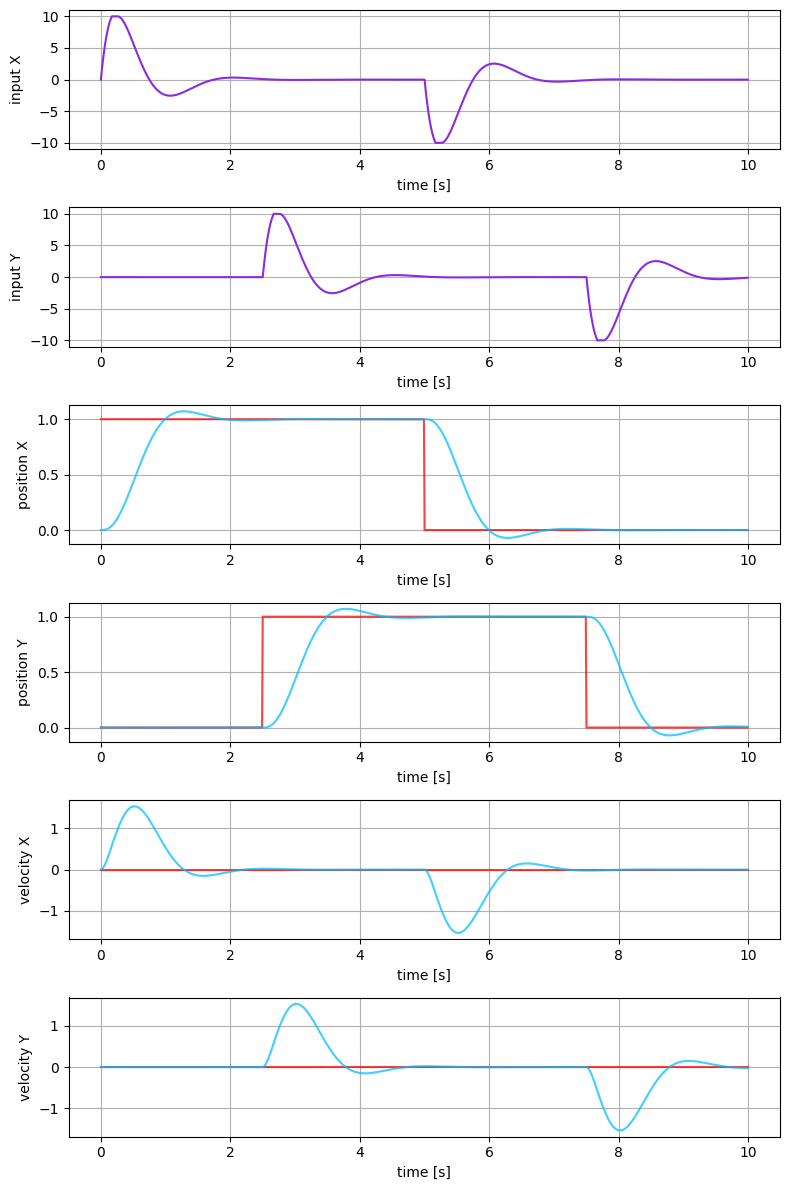

In [9]:
ds_lqr = PositionModel(tau, k, dt)

x_lqr           = numpy.zeros((ds_lqr.a.shape[0], 1))
integral_action = numpy.zeros((ds_lqr.b.shape[1], 1))

t_lqr      = []
u_lqr_log  = []
xr_lqr_log = []
x_lqr_log  = []

for n in range(n_steps):
    Xr = get_required(n, n_steps, prediction_horizon, ds_lqr.a.shape[0])

    # LQR uses only the current reference (first 4 states)
    xr_now = Xr[0:4]

    u, integral_action = lqr_controller.forward(xr_now, x_lqr, integral_action)
    x_lqr, _ = ds_lqr.forward(x_lqr, u)

    t_lqr.append(n * dt)
    u_lqr_log.append(u[:, 0])
    xr_lqr_log.append(xr_now[:, 0])
    x_lqr_log.append(x_lqr[:, 0])

t_lqr      = numpy.array(t_lqr)
u_lqr_log  = numpy.array(u_lqr_log)
xr_lqr_log = numpy.array(xr_lqr_log)
x_lqr_log  = numpy.array(x_lqr_log)

AILibs.plot_cl_response(
    t_lqr, u_lqr_log, xr_lqr_log, x_lqr_log,
    "plots/trajectory_lqr_result.png",
    ["input X", "input Y"],
    ["position X", "position Y", "velocity X", "velocity Y"]
)

LQR tracks the trajectory but **reacts only after** the reference changes.
At each corner the controller sees the new setpoint and starts correcting — this causes lag.

## 10. MPC Simulation

/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:68: RuntimeWarning: divide by zero encountered in matmul
  e = Xr - self.Phi @ x
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:68: RuntimeWarning: overflow encountered in matmul
  e = Xr - self.Phi @ x
/Users/michal/projects/ai_libs/libs/AILibs/control/libs_mpc/mpc_analytical.py:68: RuntimeWarning: invalid value encountered in matmul
  e = Xr - self.Phi @ x


<Figure size 640x480 with 0 Axes>

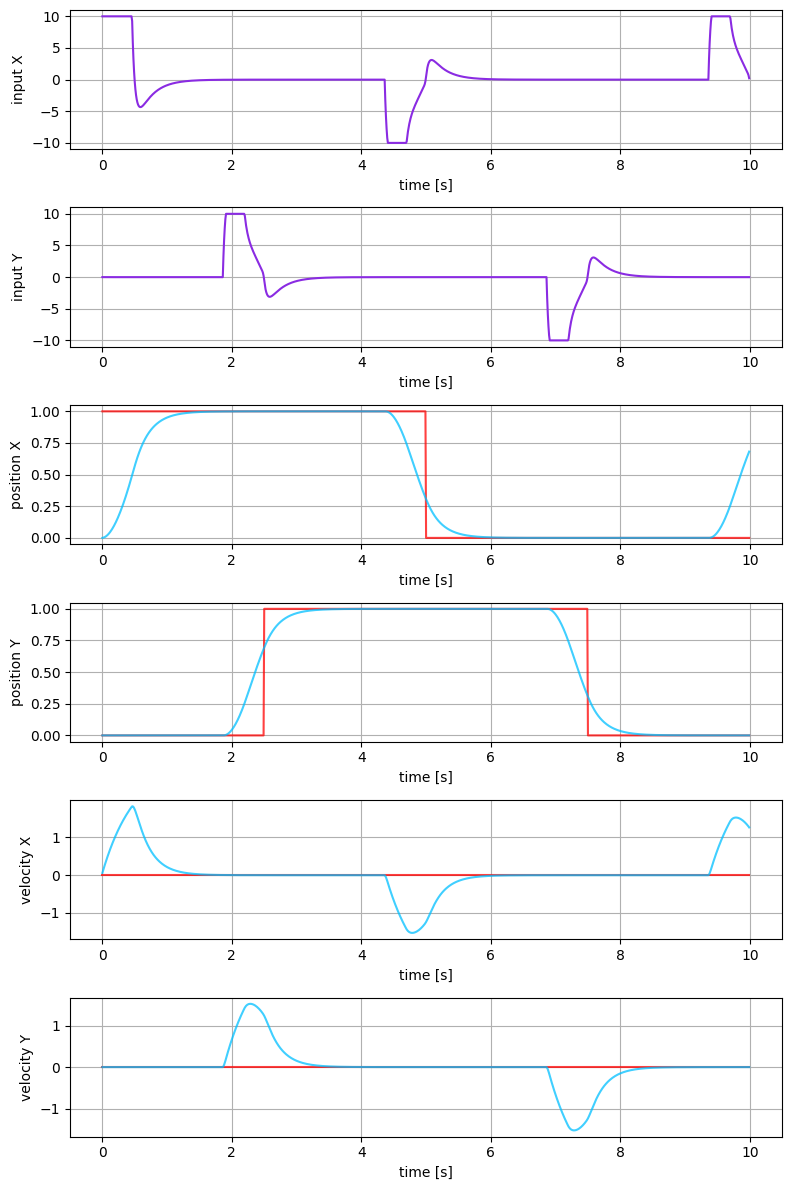

In [10]:
ds_mpc = PositionModel(tau, k, dt)

x_mpc = numpy.zeros((ds_mpc.a.shape[0], 1))

t_mpc      = []
u_mpc_log  = []
xr_mpc_log = []
x_mpc_log  = []

for n in range(n_steps):
    # MPC receives the full future trajectory
    Xr = get_required(n, n_steps, prediction_horizon, ds_mpc.a.shape[0])

    u = mpc_controller.forward_traj(Xr, x_mpc)
    x_mpc, _ = ds_mpc.forward(x_mpc, u)

    t_mpc.append(n * dt)
    u_mpc_log.append(u[:, 0])
    xr_mpc_log.append(Xr[0:4, 0])
    x_mpc_log.append(x_mpc[:, 0])

t_mpc      = numpy.array(t_mpc)
u_mpc_log  = numpy.array(u_mpc_log)
xr_mpc_log = numpy.array(xr_mpc_log)
x_mpc_log  = numpy.array(x_mpc_log)

AILibs.plot_cl_response(
    t_mpc, u_mpc_log, xr_mpc_log, x_mpc_log,
    "plots/trajectory_mpc_result.png",
    ["input X", "input Y"],
    ["position X", "position Y", "velocity X", "velocity Y"]
)

MPC **anticipates** the upcoming corners by looking ahead 64 steps.
It begins decelerating and steering *before* the reference changes, resulting in tighter tracking.

## 11. Comparison: LQR vs MPC

Plot both controllers' position tracking side by side.

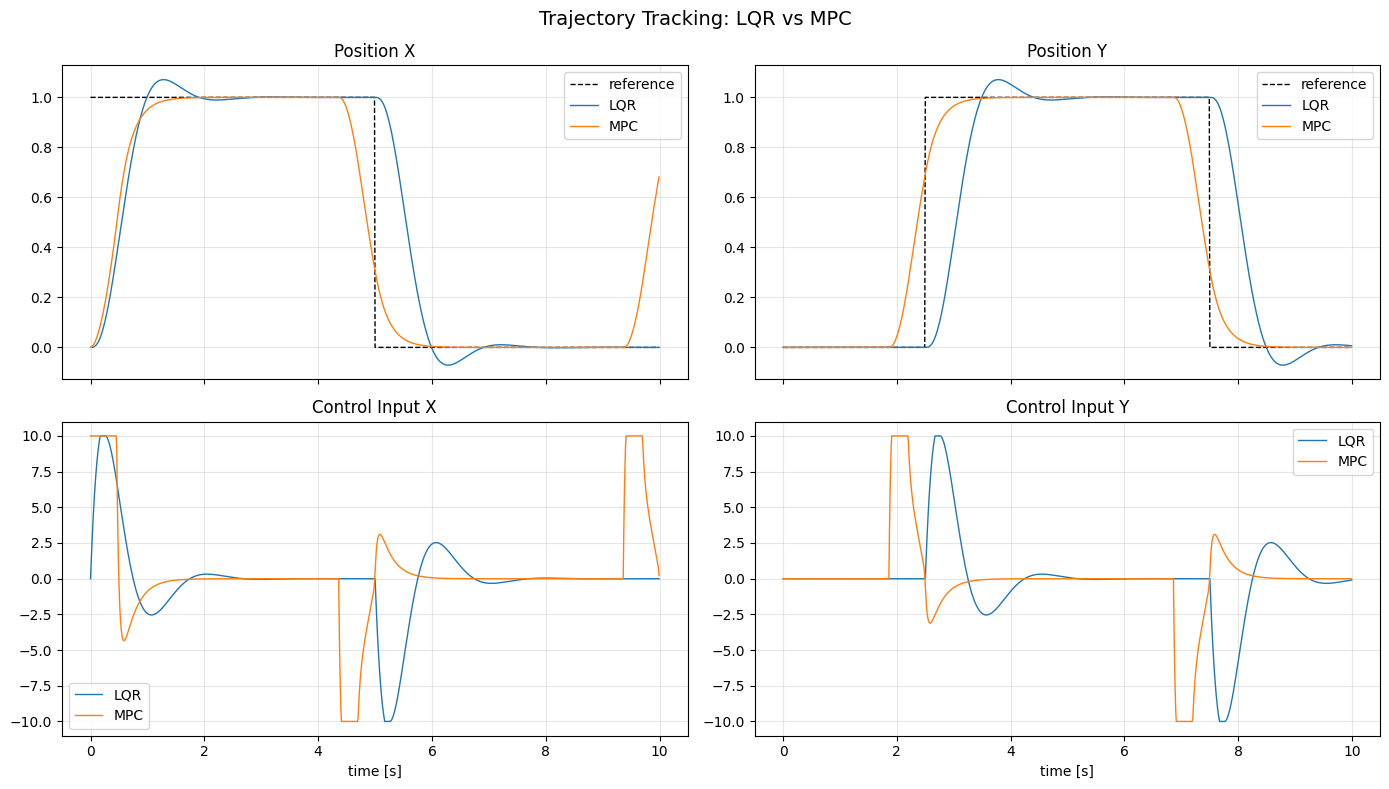

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle("Trajectory Tracking: LQR vs MPC", fontsize=14)

# Position X
axes[0, 0].set_title("Position X")
axes[0, 0].plot(t_lqr, xr_lqr_log[:, 0], "k--", label="reference", linewidth=1)
axes[0, 0].plot(t_lqr, x_lqr_log[:, 0],  label="LQR", linewidth=1)
axes[0, 0].plot(t_mpc, x_mpc_log[:, 0],   label="MPC", linewidth=1)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Position Y
axes[0, 1].set_title("Position Y")
axes[0, 1].plot(t_lqr, xr_lqr_log[:, 1], "k--", label="reference", linewidth=1)
axes[0, 1].plot(t_lqr, x_lqr_log[:, 1],  label="LQR", linewidth=1)
axes[0, 1].plot(t_mpc, x_mpc_log[:, 1],   label="MPC", linewidth=1)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Control input X
axes[1, 0].set_title("Control Input X")
axes[1, 0].plot(t_lqr, u_lqr_log[:, 0], label="LQR", linewidth=1)
axes[1, 0].plot(t_mpc, u_mpc_log[:, 0], label="MPC", linewidth=1)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel("time [s]")

# Control input Y
axes[1, 1].set_title("Control Input Y")
axes[1, 1].plot(t_lqr, u_lqr_log[:, 1], label="LQR", linewidth=1)
axes[1, 1].plot(t_mpc, u_mpc_log[:, 1], label="MPC", linewidth=1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel("time [s]")

plt.tight_layout()
plt.savefig("plots/trajectory_lqr_vs_mpc.png", dpi=150)
plt.show()

## 12. Cost Metrics

In [12]:
def compute_cost(x):
    return numpy.sum(numpy.square(x))

# LQR costs
lqr_u_cost = compute_cost(u_lqr_log)
lqr_x_cost = compute_cost(xr_lqr_log - x_lqr_log)

# MPC costs
mpc_u_cost = compute_cost(u_mpc_log)
mpc_x_cost = compute_cost(xr_mpc_log - x_mpc_log)

print(f"{'Controller':<12} {'Control Cost':>14} {'Tracking Cost':>15}")
print(f"{'-'*43}")
print(f"{'LQR':<12} {lqr_u_cost:>14.3f} {lqr_x_cost:>15.3f}")
print(f"{'MPC':<12} {mpc_u_cost:>14.3f} {mpc_x_cost:>15.3f}")
print()
print(f"MPC tracking error reduction: {(1 - mpc_x_cost/lqr_x_cost)*100:.1f}%")

Controller     Control Cost   Tracking Cost
-------------------------------------------
LQR               15826.906         670.453
MPC               20832.627         604.529

MPC tracking error reduction: 9.8%


## 13. 2D Trajectory Plot (XY Plane)

Visualise the actual paths traced by each controller in the XY plane.

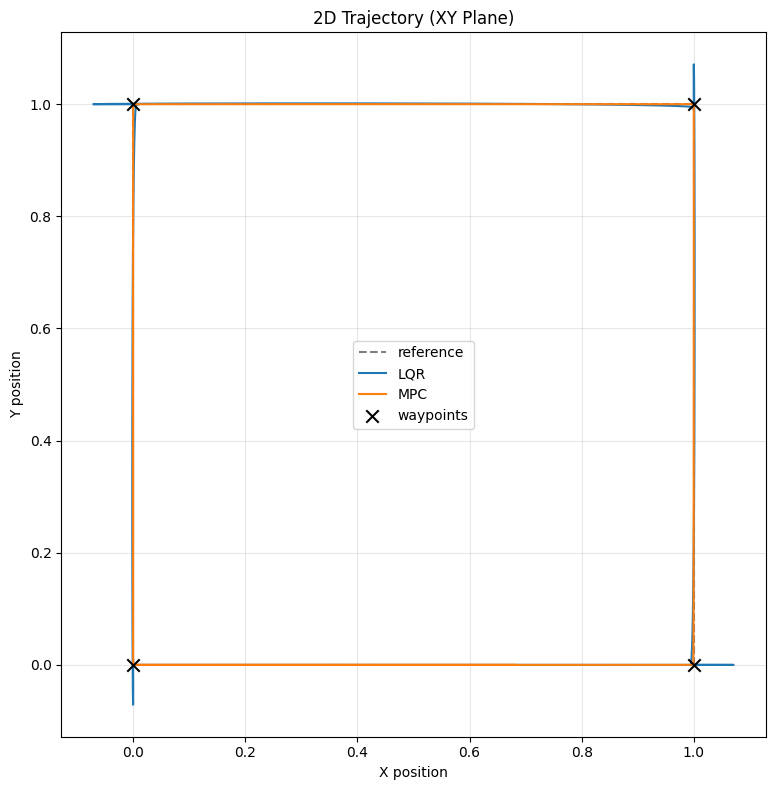

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("2D Trajectory (XY Plane)")

ax.plot(xr_lqr_log[:, 0], xr_lqr_log[:, 1], "k--", label="reference", linewidth=1.5, alpha=0.5)
ax.plot(x_lqr_log[:, 0],  x_lqr_log[:, 1],  label="LQR", linewidth=1.5)
ax.plot(x_mpc_log[:, 0],  x_mpc_log[:, 1],   label="MPC", linewidth=1.5)

# mark waypoints
waypoints = numpy.array([[1, 0], [1, 1], [0, 1], [0, 0]])
ax.scatter(waypoints[:, 0], waypoints[:, 1], c="black", s=80, zorder=5, marker="x", label="waypoints")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/trajectory_xy_plane.png", dpi=150)
plt.show()

## Key Takeaways

| Aspect | LQR | MPC |
|---|---|---|
| **Reference knowledge** | Current setpoint only | Full future trajectory |
| **Corner anticipation** | None — reacts after change | Begins steering early |
| **Tracking error** | Higher at transitions | Significantly lower |
| **Computation** | Constant-time matrix multiply | Optimisation at each step |
| **Tuning** | Q, R, integral gain | Q, R, prediction & control horizons |

MPC's ability to look ahead makes it fundamentally better suited for trajectory tracking
problems where the future reference is known.